In [1]:
import sys
sys.path.insert(1, '/Users/linusrandud/Documents/UoM/ERP/MscDissertation/Deep-Opt')

In [2]:
import torch

from COProblems.MKP import MKP
from COProblems.QUBO import QUBO
from Models.DOAE import DOAE
from OptimAE import OptimAEHandler
import json

In [3]:
torch.__version__

'1.12.1'

In [4]:
import wandb
import matplotlib.pyplot as plt

In [5]:
# Initialize device
device = torch.device("cpu")
print(device)

# Define the file path and problem type
filename = 'ssjsp_1000_s60_tfrdd'
problem_type = 'QUBO'
use_wandb = False  # Set to True if using Weights & Biases
check_constraints = 'lagrangian' # {'binary', 'lagrangian', None}

json_file = f'../data_gecco/ssjsp/{filename}.json'
file_paths = [f'../data_gecco/qubo/{filename}.txt']
problem_size = int(filename.split('_')[1])
problem_size

cpu


1000

In [6]:
def load_jobs_from_json(file_path):
    with open(file_path, 'r') as f:
        jobs = json.load(f)
    
    # Convert keys to integers
    jobs = {int(k): v for k, v in jobs.items()}
    
    return jobs

jobs = load_jobs_from_json(json_file)

In [7]:
jobs

{1: {'duration': 50, 'release': 0, 'deadline': 113060, 'machine': 0},
 2: {'duration': 148, 'release': 0, 'deadline': 81512, 'machine': 0},
 3: {'duration': 38, 'release': 0, 'deadline': 109761, 'machine': 0},
 4: {'duration': 21, 'release': 0, 'deadline': 82855, 'machine': 0},
 5: {'duration': 111, 'release': 0, 'deadline': 124326, 'machine': 0},
 6: {'duration': 153, 'release': 0, 'deadline': 78410, 'machine': 0},
 7: {'duration': 6, 'release': 0, 'deadline': 121522, 'machine': 0},
 8: {'duration': 234, 'release': 0, 'deadline': 115626, 'machine': 0},
 9: {'duration': 6, 'release': 0, 'deadline': 122787, 'machine': 0},
 10: {'duration': 242, 'release': 0, 'deadline': 115816, 'machine': 0},
 11: {'duration': 111, 'release': 0, 'deadline': 77785, 'machine': 0},
 12: {'duration': 203, 'release': 0, 'deadline': 121823, 'machine': 0},
 13: {'duration': 167, 'release': 0, 'deadline': 85103, 'machine': 0},
 14: {'duration': 23, 'release': 0, 'deadline': 119944, 'machine': 0},
 15: {'duratio

In [8]:
def calculate_percentage(data):
    # Determine the minimum release value and maximum deadline value in the dictionary
    min_release = min(item['release'] for item in data.values())
    max_deadline = max(item['deadline'] for item in data.values())

    # Total number of entries in the dictionary
    total_entries = len(data)
    
    # Count the number of entries with release == min_release and deadline == max_deadline
    count_matching_entries = sum(
        1 for item in data.values() if item['release'] == min_release and item['deadline'] == max_deadline
    )
    
    # Calculate the percentage
    percentage = (count_matching_entries / total_entries) * 100
    
    print(f'Problem instance has {percentage}% slackness')

# Parameters
params = {
    'change_tolerance': 50,
    'problem_size': problem_size,
    'pop_size': problem_size*10,
    'dropout_prob': 0.2,
    'l1_coef': 0.0001,
    'l2_coef': 0.0001,
    'learning_rate': 0.002,
    'max_depth': 6,
    'compression_ratio': 0.8,
    'problem_instance_id': 0,
    'deepest_only': False,
    'encode': True,
    'repair_solutions': True,
    'patience': 5,  # Number of iterations to wait
    'delta_mean_population': 0.1,  # Threshold for mean population change
    'check_constraints': check_constraints,
    'penalty_mult': 5
}

# Initialize problem
if problem_type == 'QUBO':
    problem = QUBO(file_paths[0], params['problem_instance_id'], device)
    if check_constraints:
        problem.jobs = jobs
        calculate_percentage(jobs)
elif problem_type == 'MKP':
    problem = MKP(file_paths[0], file_paths[1], params['problem_instance_id'], device)
else:
    raise ValueError("Unsupported problem type")

# Unpack parameters
change_tolerance = params['change_tolerance']
problem_size = params['problem_size']
pop_size = params['pop_size']
dropout_prob = params['dropout_prob']
l1_coef = params['l1_coef']
l2_coef = params['l2_coef']
lr = params['learning_rate']
max_depth = params['max_depth']
compression_ratio = params['compression_ratio']
hidden_size = problem_size

# Initialize model and handler
model = DOAE(problem_size, dropout_prob, device)
handler = OptimAEHandler(model, problem, device)

if use_wandb:
    if check_constraints:
        wandb.init(project="Deep Optimization with Constraints", tags=[problem_type, 'Check Constraints'])
    else:
        wandb.init(project="Deep Optimization with Constraints", tags=[problem_type])
    wandb.config.update(params)
    wandb.log_artifact(file_paths[0], type='dataset')
    if problem_type == 'MKP':
        wandb.log_artifact(file_paths[1], type='dataset')

    # Log the job parameters as a separate file if needed
    job_params_path = 'job_params.json'
    with open(job_params_path, 'w') as f:
        json.dump(jobs, f)
    wandb.log_artifact(job_params_path, type='dataset')

# Generate initial population
population, fitnesses = handler.generate_population(pop_size, params['check_constraints'], params['penalty_mult'])
population, fitnesses, _, _ = handler.hilldescent(population, fitnesses, change_tolerance, params['check_constraints'], params['penalty_mult'])
handler.print_statistics_min(fitnesses)

total_eval = 0
depth = 0

# Store metrics for custom plotting
mean_fitnesses = []
min_max_fitnesses = []
total_evaluations = []
mean_fitness_changes = []

while True:
    if depth < max_depth:
        print("Adding layer")
        hidden_size = round(hidden_size * compression_ratio)
        model.transition(hidden_size)
        depth += 1
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_coef)
    
    print("Learning from population")
    handler.learn_from_population(population, optimizer, l1_coef=l1_coef, batch_size=pop_size)
    
    print("Optimising population")
    population, fitnesses, evaluations, done = handler.optimise_solutions_min(
        population, fitnesses, change_tolerance, encode=params['encode'], repair_solutions=params['repair_solutions'], deepest_only=params['deepest_only'], 
        check_constraints=params['check_constraints'], penalty_mult=params['penalty_mult']
    )
    handler.print_statistics_min(fitnesses)

    mean_fitness = fitnesses.mean().item()
    min_max_fitness = fitnesses.min().item()
    total_eval += evaluations

    mean_fitnesses.append(mean_fitness)
    min_max_fitnesses.append(min_max_fitness)
    total_evaluations.append(total_eval)

    if use_wandb:
        wandb.log({
            "mean_fitness": mean_fitness,
            "min_max_fitness": min_max_fitness,
            "total_eval": total_eval,
            "depth": depth
        })

    print(f"Evaluations: {total_eval}")
    
    if len(mean_fitnesses) > 1:
        mean_fitness_change = abs(mean_fitnesses[-1] - mean_fitnesses[-2])
        mean_fitness_changes.append(mean_fitness_change)
        
        if len(mean_fitness_changes) >= params['patience']:
            recent_changes = mean_fitness_changes[-params['patience']:]
            if all(change < params['delta_mean_population'] for change in recent_changes):
                print(f"Stopping early due to no significant change in mean fitness over the last {params['patience']} iterations.")
                break
    
    if done:
        print(f"Optimum solution found.")
        break

Instance has been loaded
Problem instance has 0.1% slackness


KeyError: 477

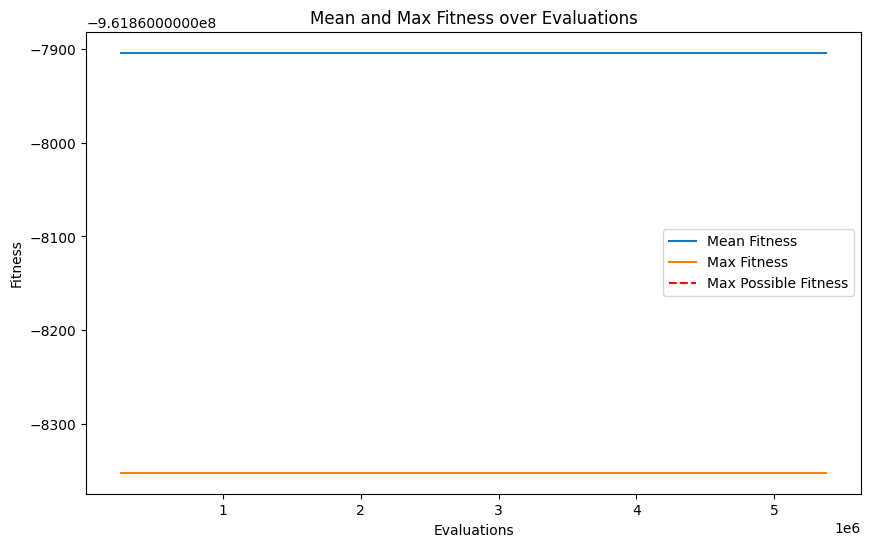

In [ ]:
# -177528992.0, -961868288.0

plt.figure(figsize=(10, 6))
plt.plot(total_evaluations, mean_fitnesses, label='Mean Fitness')
plt.plot(total_evaluations, min_max_fitnesses, label='Max Fitness')
plt.axhline(y=problem.max_fitness, color='r', linestyle='--', label='Max Possible Fitness')
plt.xlabel('Evaluations')
plt.ylabel('Fitness')
plt.title('Mean and Max Fitness over Evaluations')
plt.legend()

# Save plot to W&B
# wandb.log({"fitness_plot": wandb.Image(plt)})

In [ ]:
population

tensor([[ 1.,  1., -1.,  ..., -1., -1.,  1.],
        [ 1., -1., -1.,  ..., -1.,  1., -1.],
        [ 1., -1., -1.,  ...,  1.,  1., -1.],
        ...,
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ...,  1., -1.,  1.],
        [ 1.,  1., -1.,  ..., -1., -1.,  1.]])

In [ ]:
fitnesses, len(fitnesses)

(tensor([-9.6187e+08, -9.6187e+08, -9.6187e+08,  ..., -9.6187e+08,
         -9.6187e+08, -9.6187e+08]),
 5000)

In [ ]:
import numpy as np

In [ ]:
def find_extreme_indices(fitnesses, mode='high'):
    """
    Returns the indices of the highest or lowest values in the list based on the mode.

    Args:
        fitnesses (list or torch.Tensor): A list or tensor of fitness values.
        mode (str): A string that can be either 'high' or 'low'. Defaults to 'high'.

    Returns:
        list: A list of indices corresponding to the extreme values.
    """
    if mode not in ['high', 'low']:
        raise ValueError("Mode should be either 'high' or 'low'")

    if mode == 'high':
        extreme_value = max(fitnesses)
    else:
        extreme_value = min(fitnesses)

    return [i for i, value in enumerate(fitnesses) if value == extreme_value]

In [ ]:
def convert_tensor_to_unique_np_arrays(tensor):
    # Convert the tensor to a numpy array
    np_array = tensor.numpy()
    
    # Replace -1 with 0
    np_array[np_array == -1] = 0
    
    # Use a set to track unique arrays based on element ordering
    unique_arrays = set()
    
    # Create a list to store unique numpy arrays
    unique_np_arrays = []
    
    for arr in np_array:
        # Convert the array to a tuple (hashable type) for uniqueness check
        arr_tuple = tuple(arr)
        
        if arr_tuple not in unique_arrays:
            unique_arrays.add(arr_tuple)
            unique_np_arrays.append(arr)
    
    # Convert the list of unique arrays back to a numpy array
    unique_np_array = np.array(unique_np_arrays)
    
    return unique_np_array

In [ ]:
def get_solutions(population, fitnesses, mode='low'):
    return convert_tensor_to_unique_np_arrays(population[find_extreme_indices(fitnesses, mode)])

In [ ]:
def load_jobs_from_json(file_path):
    with open(file_path, 'r') as f:
        jobs = json.load(f)
    
    # Convert keys to integers
    jobs = {int(k): v for k, v in jobs.items()}
    
    return jobs

jobs = load_jobs_from_json(json_file)

In [ ]:
import numpy as np

def check_constraints(solution, jobs):
    machine_jobs = [[], []]
    makespans = [0, 0]
    infeasible_count = 0
    
    # Distribute jobs to the respective machines
    for job_index, job_assignment in enumerate(solution):
        machine = int(job_assignment)
        job_key = job_index + 1
        job = jobs[job_key]
        machine_jobs[machine].append((job_key, job))
    
    # Validate each machine's job schedule
    for machine, assigned_jobs in enumerate(machine_jobs):
        current_time = 0
        # Sort jobs by release date first, then by deadline
        for job_key, job in sorted(assigned_jobs, key=lambda x: (x[1]['deadline'], x[1]['release'])):
            # Ensure the job starts at the earliest possible time that meets its release date
            if current_time < job['release']:
                current_time = job['release']
            current_time += job['duration']
            # Check if the job finishes before its deadline
            if current_time > job['deadline']:
                infeasible_count += 1
                print(f"Machine and Job makes it not feasible: {machine}/{job_key}")
                print(f"Current time: {current_time}, Job's deadline: {job['deadline']}")
        makespans[machine] = current_time
    
    if infeasible_count > 0:
        return False, infeasible_count, makespans
    return True, infeasible_count, makespans


In [ ]:
solutions = get_solutions(population, fitnesses, mode='low')
len(solutions)

4

In [ ]:
import math
print(len(solutions)/math.comb(len(solutions[0])*2, len(solutions[0])))

1.4799015991256108e-299


In [ ]:
solutions, solutions[0]

(array([[0., 0., 1., ..., 1., 0., 0.],
        [0., 1., 0., ..., 1., 1., 1.],
        [0., 1., 0., ..., 1., 1., 1.],
        [1., 0., 1., ..., 1., 1., 0.]], dtype=float32),
 array([0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1.,
        0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
        1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0.,
        1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1.,
        0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
        1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1.,
        1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1.,
        1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
        1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1.,

In [ ]:
all_makespans = []

for i, solution in enumerate(solutions):    
    machine_jobs = [[], []]
    makespans = [0, 0]

    # Distribute jobs to the respective machines
    for job_index, job_assignment in enumerate(solution):
        machine = int(job_assignment)
        job_key = job_index + 1
        job = jobs[job_key]
        makespans[machine] += job['duration']
    
    all_makespans.append(makespans)

In [ ]:
all_makespans

[[28704, 33324], [29258, 32770], [29742, 32286], [30983, 31045]]

In [ ]:
# Check all solutions
total_feasible_solutions = 0
total_infeasible_solutions = 0
logs = []

for i, solution in enumerate(solutions):
    feasible, infeasible_jobs, makespans = check_constraints(solution, jobs)
    if feasible:
        total_feasible_solutions += 1
    else:
        total_infeasible_solutions += 1
    
    # Accumulate logs
    logs.append({
        'solution_number': i + 1,
        'feasible': feasible,
        'infeasible_jobs': infeasible_jobs,
        'makespans': makespans
    })
    
    print(f"Solution {i + 1}: Feasible = {feasible}, Infeasible Jobs = {infeasible_jobs}, Makespans = {makespans}")
    print('')

# Log all solutions at once
# wandb.log({
#     'solutions': logs,
#     'total_feasible_solutions_count': total_feasible_solutions,
#     'total_infeasible_solutions': total_infeasible_solutions
# })

print(f'total_feasible_solutions: {total_feasible_solutions}')
print(f'total_infeasible_solutions: {total_infeasible_solutions}')

Machine and Job makes it not feasible: 1/348
Current time: 56710, Job's deadline: 56635
Machine and Job makes it not feasible: 1/393
Current time: 56964, Job's deadline: 56677
Machine and Job makes it not feasible: 1/276
Current time: 57011, Job's deadline: 56700
Machine and Job makes it not feasible: 1/363
Current time: 57198, Job's deadline: 56709
Machine and Job makes it not feasible: 1/92
Current time: 57434, Job's deadline: 56849
Machine and Job makes it not feasible: 1/243
Current time: 57449, Job's deadline: 57005
Machine and Job makes it not feasible: 1/337
Current time: 57508, Job's deadline: 57114
Machine and Job makes it not feasible: 1/154
Current time: 57726, Job's deadline: 57123
Machine and Job makes it not feasible: 1/316
Current time: 57954, Job's deadline: 57211
Machine and Job makes it not feasible: 1/191
Current time: 58108, Job's deadline: 57235
Machine and Job makes it not feasible: 1/13
Current time: 58111, Job's deadline: 57242
Machine and Job makes it not feasi

In [ ]:
# # Finish the W&B run
# wandb.finish()

In [ ]:
# Machine and Job makes it not feasible: 0/47
# Current time: 2816, Job's deadline: 2794
# Solution 1: Feasible = False, Infeasible Jobs = 1, Makespans = [2816, 2789]

# total_feasible_solutions: 0
# total_infeasible_solutions: 1